In [1]:
import pandas as pd
from vidigi.process_mapping import add_sim_timestamp, discover_dfg, dfg_to_graphviz, dfg_to_cytoscape

In [2]:
event_log = pd.read_csv("sample_event_log_10_day_10_run.csv")

event_log_single = event_log[event_log["run"]==1]

event_log.head()

,entity_id,pathway,event_type,event,time,resource_id,run
0,1,Simplest,arrival_departure,arrival,0.00000,NaN,0
1,1,Simplest,queue,treatment_wait_begins,0.00000,NaN,0
2,1,Simplest,resource_use,treatment_begins,0.00000,1.0,0
3,2,Simplest,arrival_departure,arrival,3.39966,NaN,0
4,2,Simplest,queue,treatment_wait_begins,3.39966,NaN,0


In [3]:
# df = event_log[(event_log["event_type"]=="queue") |
#                (event_log["event_type"]=="resource_use")].copy()

# df["activity_id"] = df.groupby("run").cumcount() + 1

# # Duplicate rows and modify them
# df_start = df.copy()
# df_start["lifecycle_id"] = "start"

In [4]:
# df_end = df.copy()
# df_end["lifecycle_id"] = "complete"

# # Shift timestamps for 'end' rows
# df_end["time"] = df_end["time"].shift(-1)

In [5]:
# # Combine and sort
# df_combined = pd.concat([df_start, df_end]).sort_index(kind="stable")

# # Drop last 'end' row (since there’s no next row to get a timestamp from)
# df_combined = df_combined[:-1]

# df_combined.to_csv("pm_log.csv", index=False)

# df_combined.head(30)

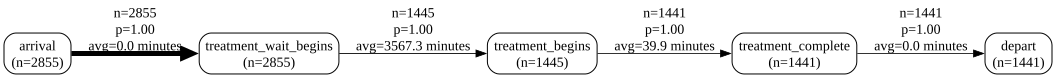

In [6]:
df_timestamp = add_sim_timestamp(event_log_single)

nodes, edges = discover_dfg(df_timestamp)

dot = dfg_to_graphviz(
    nodes,
    edges,
    min_frequency=5
)

dot


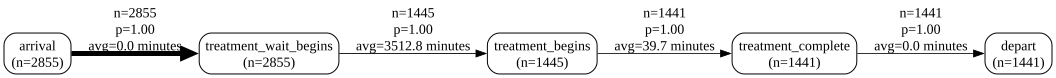

In [7]:
dfg_to_graphviz(
    nodes,
    edges,
    min_frequency=5,
    time_metric="median"
)

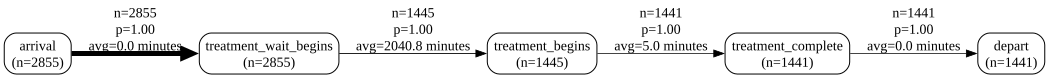

In [8]:
dfg_to_graphviz(
    nodes,
    edges,
    min_frequency=5,
    time_metric="standard_deviation"
)

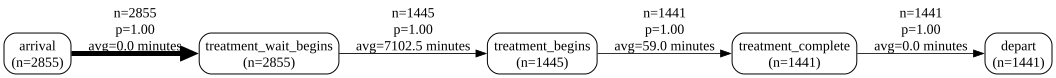

In [9]:
dfg_to_graphviz(
    nodes,
    edges,
    min_frequency=5,
    time_metric="max"
)

# A more complex example - stroke dataset

In [10]:
stroke_df = pd.read_csv("event_log_stroke.csv")
stroke_df.head()

,Unnamed: 0,id,patient_diagnosis_type,thrombolysis,admission_avoidance,advanced_ct_pathway,arrived_ooh,event,time,event_type,resource_id
0,0,1,I,True,False,True,True,clock_start,0.000000,arrival_departure,NaN
1,1,2,I,True,False,True,True,clock_start,415.319713,arrival_departure,NaN
2,2,3,TIA,False,True,True,False,clock_start,480.000000,arrival_departure,NaN
3,3,4,I,True,False,True,False,clock_start,481.157251,arrival_departure,NaN
4,4,5,I,True,False,True,False,clock_start,898.765362,arrival_departure,NaN


Let's tidy it up a bit!

In [11]:
stroke_df["event"] = stroke_df["event"].apply(lambda x: x.replace("_time","").replace("_", " "))

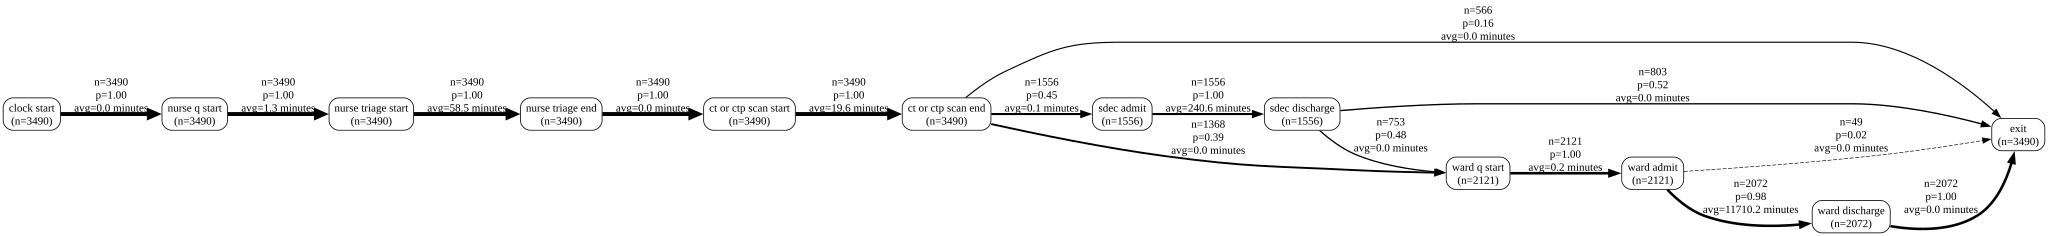

In [12]:
stroke_df_timestamp = add_sim_timestamp(stroke_df)

nodes, edges = discover_dfg(stroke_df_timestamp, case_col="id")

dot = dfg_to_graphviz(
    nodes,
    edges,
    min_frequency=5
)

dot


In [13]:
type(dot)

graphviz.graphs.Digraph

In [14]:
dot = dfg_to_graphviz(
    nodes,
    edges,
    min_frequency=5,
    return_image=True,
    format="png"
)

dot


b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\rx\x00\x00\x01\x8f\x08\x06\x00\x00\x00\\\x10Y\xc0\x00\x00\x00\x06bKGD\x00\xff\x00\xff\x00\xff\xa0\xbd\xa7\x93\x00\x00 \x00IDATx\x9c\xec\xdd\x7f\x94\x95\xe5a\'\xf0\xef\x1d\xf1W\x840d\x11\x14\x92!\xc5\x06\xd4\x9a`\xd4$$`\xcc\x82\xbbf\x89s{L\x82\x11\xbbh\xb3u\xc8\x10\xa3\xb1\x85&\xa8\x8ci\n\xa7J\x1d0\xa9\x1a\x901\xadH\x8fN\xc5l*W\xf3c\x0f\x12\xb5\t\x8c&6\x90\x1a\xadD\\\x185\xca`\x84\xc1\x82"\x81\xbb\x7f\xb8s+\x82\x08\x88^`>\x9fs\xde\xc3\xbd\xef\xfb\xbc\xcf\xfd\xde\x11\x9fs\x80\xfb\xbdO\xa1\\.\x97\x03\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xc0;\xae\xa6\xda\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xba+\x05/\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x80*Q\xf0\x02\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xa8\x12\x05/\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x80*Q\xf0\x02\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\xa8\x12\x05/\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x80*Q\xf0\x02\x00\x00\x00\

In [15]:
type(dot)

bytes

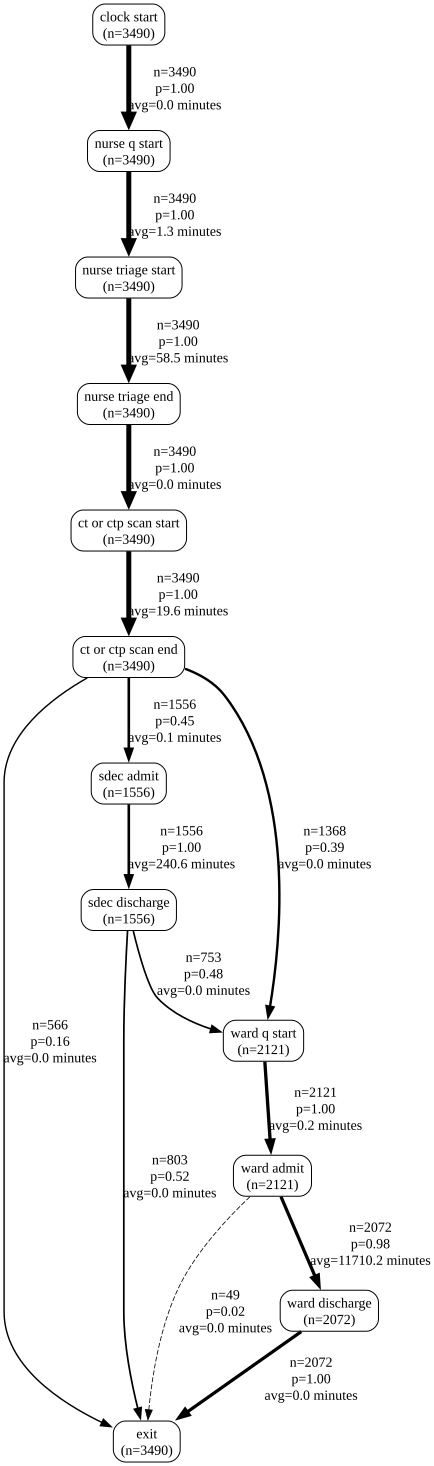

In [16]:
dot = dfg_to_graphviz(
    nodes,
    edges,
    min_frequency=5,
    direction="TD"
)

dot

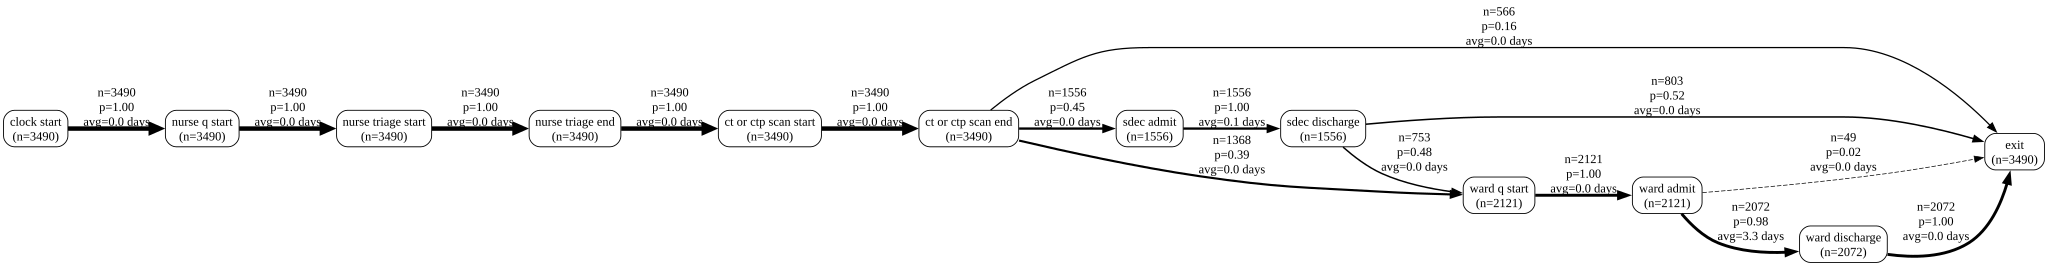

In [17]:
stroke_df["time_days"] = stroke_df["time"] / 60 / 60

stroke_df_timestamp = add_sim_timestamp(stroke_df, time_col="time_days", time_unit="days", timestamp_col="timestamp_days")

nodes, edges = discover_dfg(stroke_df_timestamp, case_col="id", timestamp_col="timestamp_days", time_unit="days")

dot = dfg_to_graphviz(
    nodes,
    edges,
    min_frequency=5,
    time_unit="days",
)

dot


In [18]:
stroke_df_timestamp.head()

,Unnamed: 0,id,patient_diagnosis_type,thrombolysis,admission_avoidance,advanced_ct_pathway,arrived_ooh,event,time,event_type,resource_id,time_days,timestamp_days
0,0,1,I,True,False,True,True,clock start,0.000000,arrival_departure,NaN,0.000000,2000-01-01 00:00:00.000000000
1,1,2,I,True,False,True,True,clock start,415.319713,arrival_departure,NaN,0.115367,2000-01-01 02:46:07.673105006
2,2,3,TIA,False,True,True,False,clock start,480.000000,arrival_departure,NaN,0.133333,2000-01-01 03:11:59.999999997
3,3,4,I,True,False,True,False,clock start,481.157251,arrival_departure,NaN,0.133655,2000-01-01 03:12:27.774025750
4,4,5,I,True,False,True,False,clock start,898.765362,arrival_departure,NaN,0.249657,2000-01-01 05:59:30.368681589


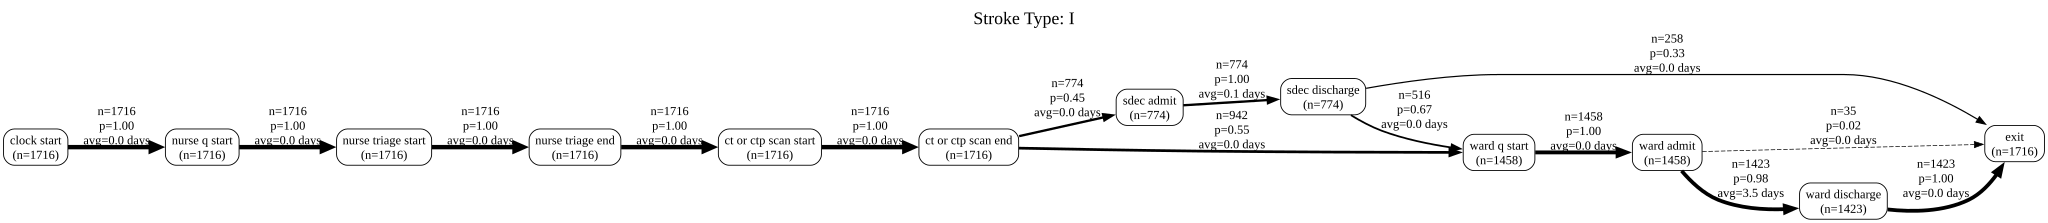

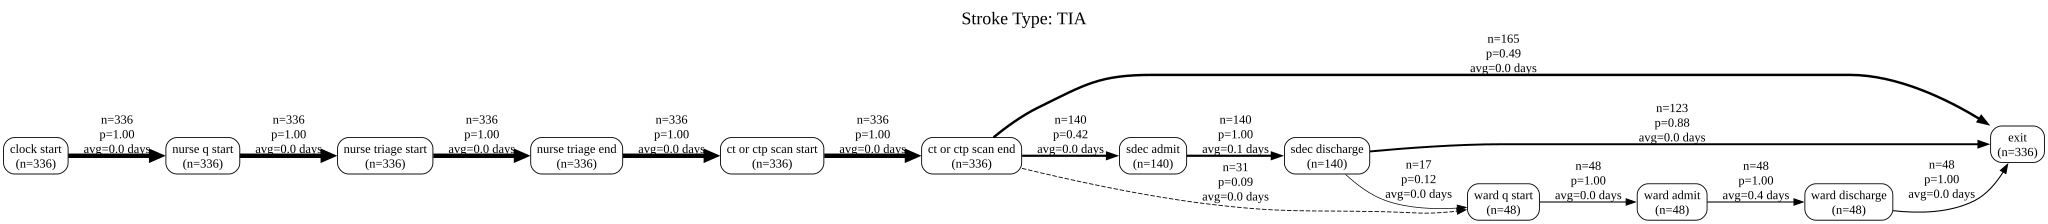

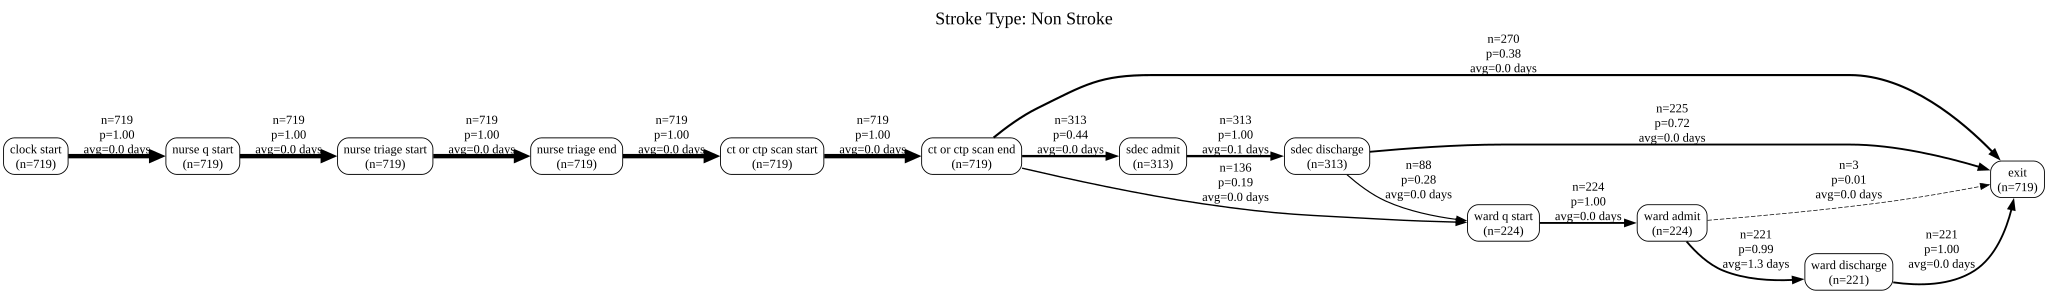

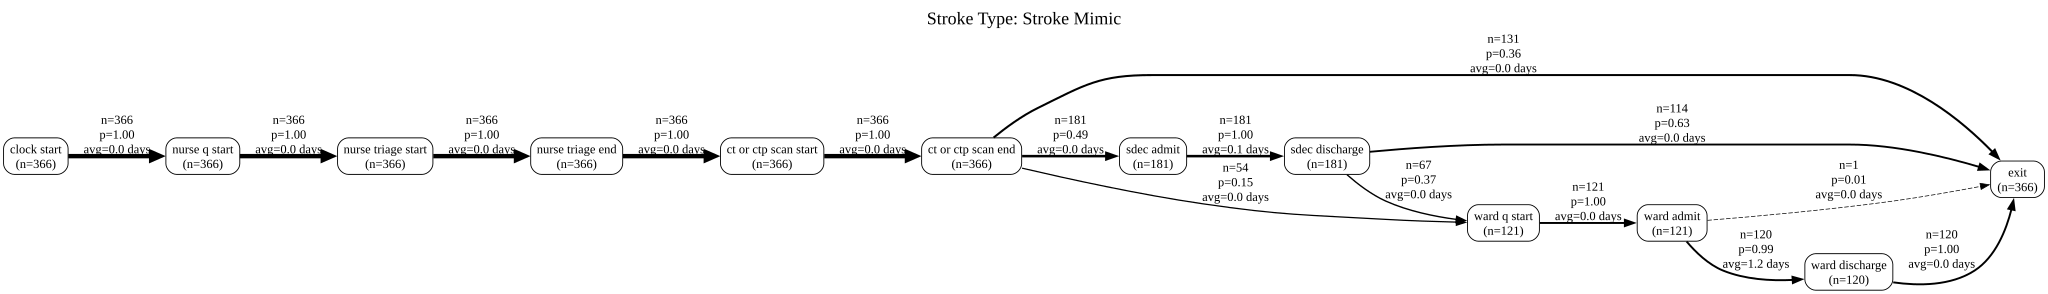

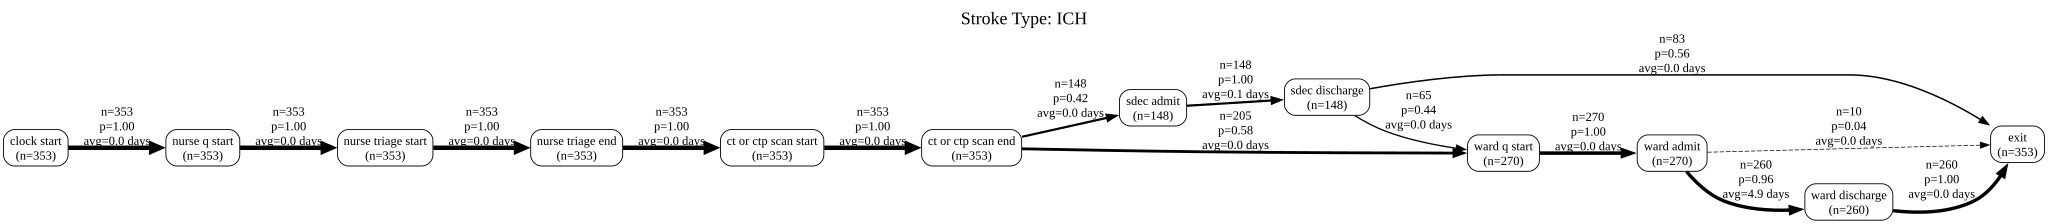

In [19]:
from IPython.display import display

for i in stroke_df_timestamp["patient_diagnosis_type"].unique():

    df = stroke_df_timestamp[stroke_df_timestamp["patient_diagnosis_type"]==i]

    nodes, edges = discover_dfg(df, case_col="id", timestamp_col="timestamp_days", time_unit="days")

    display(dfg_to_graphviz(
        nodes,
        edges,
        time_unit="days",
        title=f"Stroke Type: {i}"
    ))

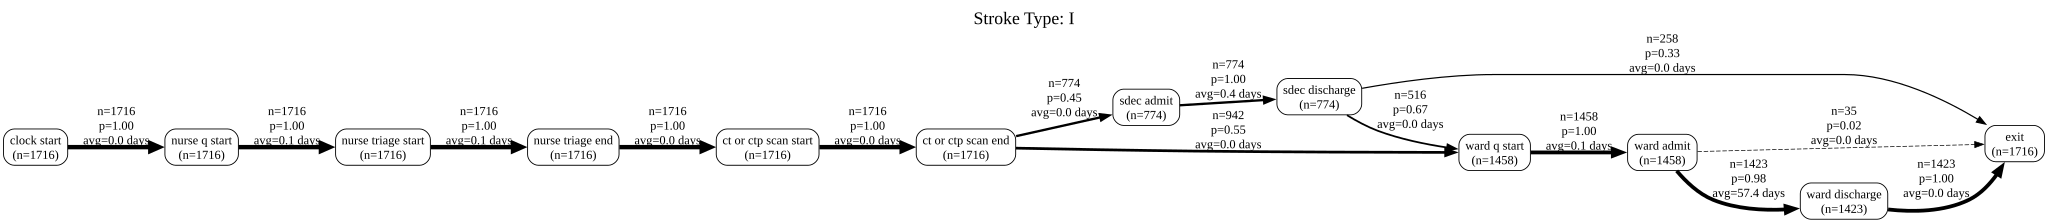

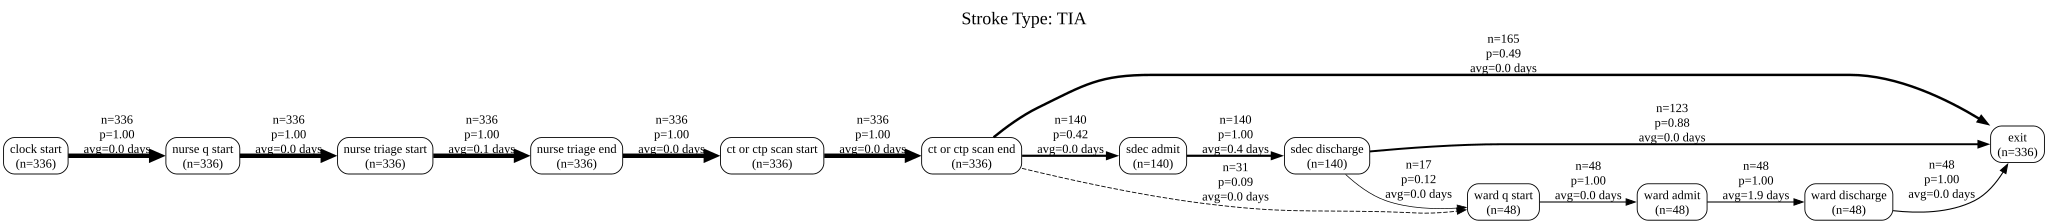

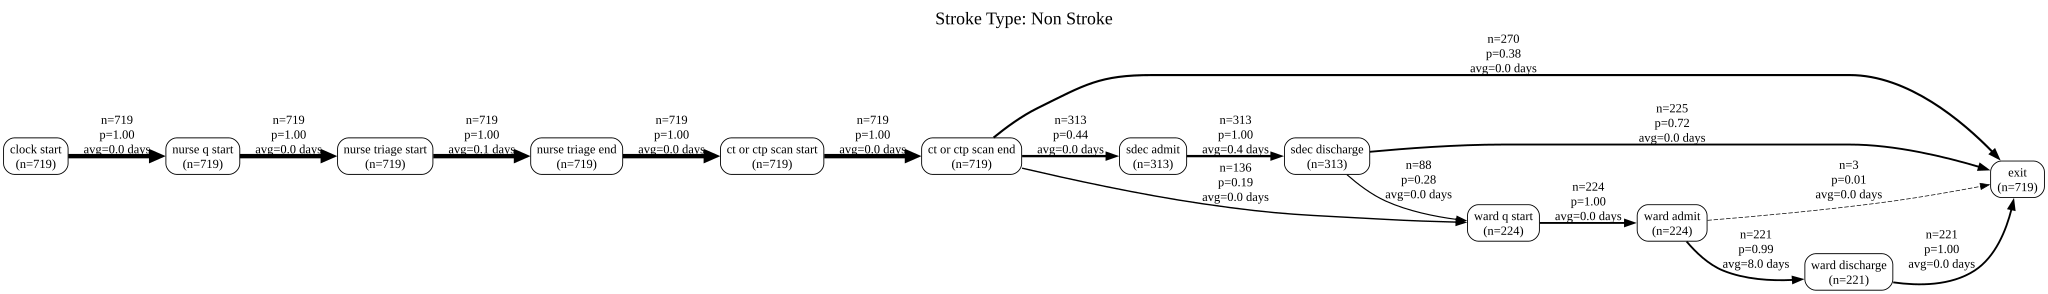

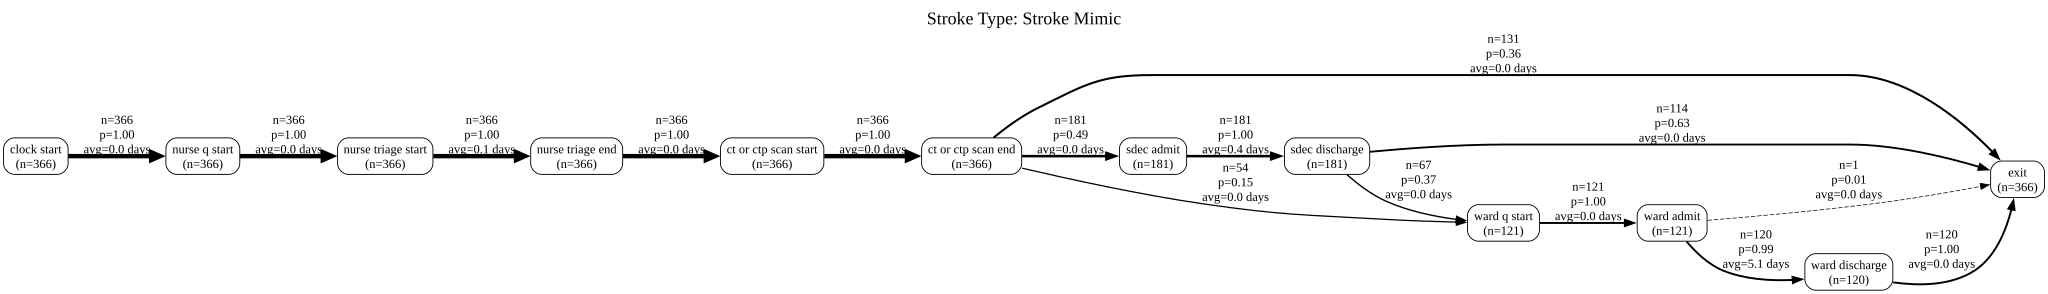

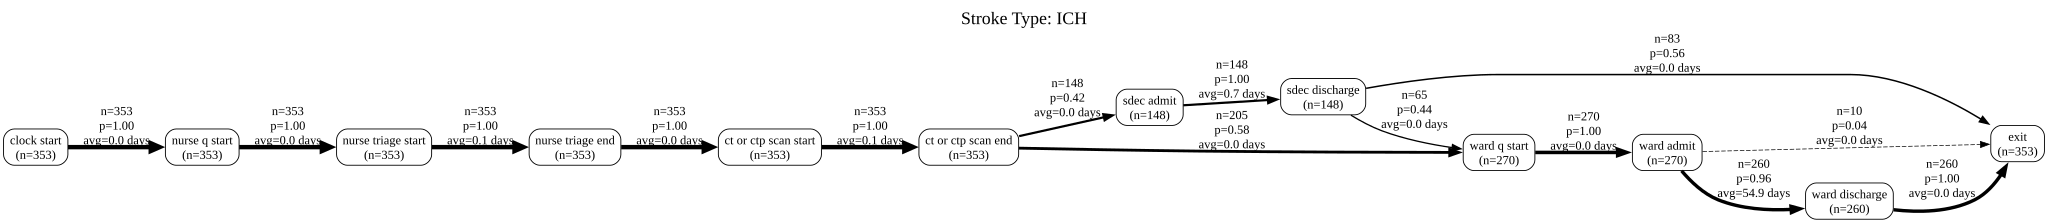

In [20]:
from IPython.display import display

for i in stroke_df_timestamp["patient_diagnosis_type"].unique():

    df = stroke_df_timestamp[stroke_df_timestamp["patient_diagnosis_type"]==i]

    nodes, edges = discover_dfg(df, case_col="id", timestamp_col="timestamp_days", time_unit="days")

    display(dfg_to_graphviz(
        nodes,
        edges,
        time_unit="days",
        title=f"Stroke Type: {i}",
        time_metric="max"
    ))

In [21]:
nodes

,activity,count
0,clock start,353
1,ct or ctp scan end,353
2,ct or ctp scan start,353
3,exit,353
4,nurse q start,353
5,nurse triage end,353
6,nurse triage start,353
7,sdec admit,148
8,sdec discharge,148
9,ward admit,270


In [22]:
edges

,source,target,frequency,mean_time,median_time,max_time,min_time,standard_deviation_time,probability
0,clock start,nurse q start,353,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
1,ct or ctp scan end,sdec admit,148,0.000000,0.000000,0.000000,0.000000,0.000000,0.419263
2,ct or ctp scan end,ward q start,205,0.000000,0.000000,0.000000,0.000000,0.000000,0.580737
3,ct or ctp scan start,ct or ctp scan end,353,0.005699,0.003851,0.059199,0.000010,0.006419,1.000000
4,nurse q start,nurse triage start,353,0.000309,0.000000,0.017985,0.000000,0.001805,1.000000
5,nurse triage end,ct or ctp scan start,353,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
6,nurse triage start,nurse triage end,353,0.017476,0.012402,0.086101,0.000008,0.017280,1.000000
7,sdec admit,sdec discharge,148,0.071392,0.040752,0.689727,0.000297,0.092255,1.000000
8,sdec discharge,exit,83,0.000000,0.000000,0.000000,0.000000,0.000000,0.560811
9,sdec discharge,ward q start,65,0.000000,0.000000,0.000000,0.000000,0.000000,0.439189


In [23]:
op = dfg_to_cytoscape(
    nodes,
    edges,
    layout_name='dagre',
    layout_orientation="LR",
    spacing_factor=1.5,
    width=1400,
    time_unit="days",
    show_metric=False)

# op.set_layout(name="cose")

# op.relayout()

display(op)

Box(children=(CytoscapeWidget(cytoscape_layout={'name': 'dagre', 'directed': True, 'animate': True, 'randomize…